In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [6]:
df = pd.read_csv(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\data\cleaned_complaints.csv"
)

In [7]:
X = df["clean_text"]

y = df["Agency Name"]

In [8]:
tfidf = TfidfVectorizer(

    max_features=5000,

    stop_words="english"
)

X_tfidf = tfidf.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,

    y,

    test_size=0.2,

    random_state=42
)

In [10]:
rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = rf_model.predict(
    X_test
)

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9972820256061798


In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                                                    precision    recall  f1-score   support

                           Department of Buildings       1.00      1.00      1.00      5393
      Department of Consumer and Worker Protection       1.00      0.96      0.98       899
                           Department of Education       1.00      0.98      0.99       129
            Department of Environmental Protection       1.00      1.00      1.00      9816
           Department of Health and Mental Hygiene       1.00      1.00      1.00      3587
                   Department of Homeless Services       1.00      0.68      0.81      1569
Department of Housing Preservation and Development       1.00      1.00      1.00     66193
                Department of Parks and Recreation       1.00      1.00      1.00      3484
                          Department of Sanitation       1.00      1.00      1.00     23412
                      Department of Transportation       1.00      1.00      1.

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

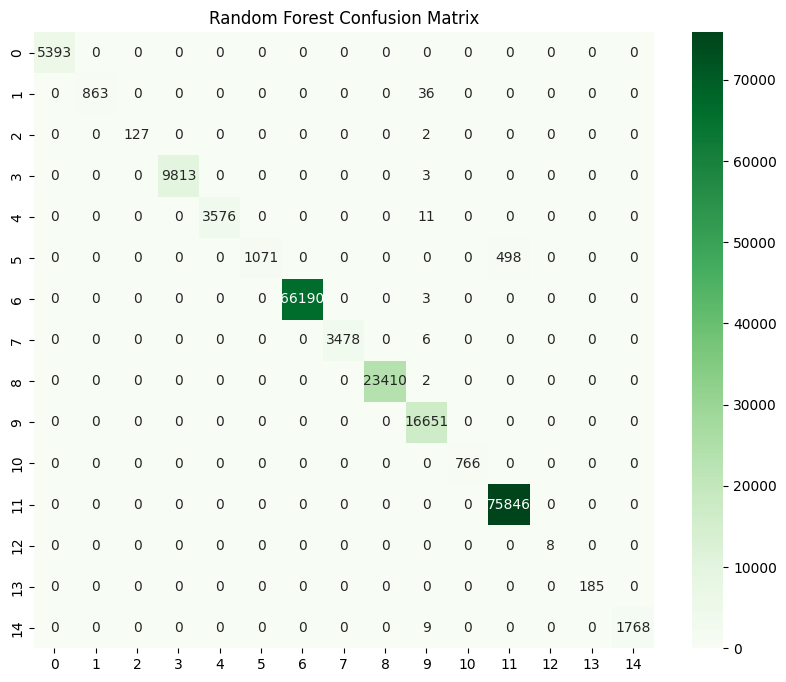

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [16]:
with open(
    r"C:\Users\G VARSHIT HARIPRASAD\Desktop\Infotact Solutions Project\Month 2 - April\AI Sentiment Analysis System 2\models/random_forest.pkl",
    "wb"
) as file:

    pickle.dump(
        rf_model,
        file
    )